# Deep K-SVD Model Testing

Test a trained Deep K-SVD checkpoint on a single image with visual comparison.


In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import matplotlib.pyplot as plt
import sys
from pathlib import Path
import seaborn as sns
import numpy as np

PROJECT_ROOT = Path.cwd().parent
IMAGE_PATH = Path(PROJECT_ROOT) / "data" / "CBSD68"
NETFLIX_PATH = Path(PROJECT_ROOT) / "data" / "netflix"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.ksvd.ksvd import ksvd, initialize_dictionary
from src.ksvd.patches import extract_patches, reconstruct_from_patches
from src.ksvd.omp import *
from src.utils.masking import create_mask, apply_mask, create_netflix_mask
from src.utils.noise import add_gaussian_noise, add_pairflip_noise, add_symmetric_noise
from src.utils.io import load_image, load_netflix_matrix
from src.utils.metrics import mse, nmse, psnr, rmse, nrmse

from experiments.config import *

In [2]:
def show_results(X, X_rec, X_noisy=None, X_masked=None, title=""):
    plt.figure(figsize=(12, 4))

    if X_noisy is not None:
        plt.subplot(1, 3, 1)
        plt.imshow(X, cmap="gray", vmin=0, vmax=255)
        plt.title("Original")
        plt.axis("off")

        plt.subplot(1, 3, 2)
        plt.imshow(X_noisy, cmap='gray', vmin=0, vmax=255)
        plt.title("Noisy")
        plt.axis("off")

        plt.subplot(1, 3, 3)
        plt.imshow(X_rec, cmap="gray", vmin=0, vmax=255)
        plt.title("Denoised")
        plt.axis("off")

    else:
        plt.subplot(1, 3, 1)
        plt.imshow(X, cmap='gray', vmin=0, vmax=255)
        plt.title("Original")
        plt.axis("off")

        plt.subplot(1, 3, 2)
        plt.imshow(X_masked, cmap='gray', vmin=0, vmax=255)
        plt.title("Observed pixels")
        plt.axis("off")

        plt.subplot(1, 3, 3)
        plt.imshow(X_rec, cmap='gray', vmin=0, vmax=255)
        plt.title("Reconstructed")
        plt.axis("off")

    plt.suptitle(title)
    plt.show()

In [2]:
RESULTS_PATH = Path(PROJECT_ROOT) / "results" / "dksvd"

IMG_PATH = RESULTS_PATH / "images"

rec = pd.read_csv(IMG_PATH / "reconstruction_results.csv")
den = pd.read_csv(IMG_PATH / "denoising_results.csv")

rec_avg = rec.groupby("missing_fraction")["PSNR"].mean()
den_avg = den.groupby("sigma")["PSNR"].mean()
rec_std = rec.groupby("missing_fraction")["PSNR"].std()
den_std = den.groupby("sigma")["PSNR"].std()

print(f"Reconstruction Observed Fraction vs. PSNR: {rec_avg}")
print(f"Denoising Noise Level vs. PSNR: {den_avg}")
print(f"Reconstruction PSNR Std Dev: {rec_std}")
print(f"Denoising PSNR Std Dev: {den_std}")

Reconstruction Observed Fraction vs. PSNR: missing_fraction
0.2    35.274362
0.4    30.797375
0.6    28.722778
Name: PSNR, dtype: float64
Denoising Noise Level vs. PSNR: sigma
12.75    32.384266
25.50    28.819164
51.00    25.681088
Name: PSNR, dtype: float64
Reconstruction PSNR Std Dev: missing_fraction
0.2    3.550105
0.4    3.590337
0.6    3.868536
Name: PSNR, dtype: float64
Denoising PSNR Std Dev: sigma
12.75    2.313889
25.50    2.538647
51.00    2.646037
Name: PSNR, dtype: float64


In [ ]:
import torch
from scipy import linalg

from experiments.config import *

# Add Deep-K-SVD to path
DEEP_KSVD_PATH = Path(PROJECT_ROOT) / "experiments" / "Deep-K-SVD"
if str(DEEP_KSVD_PATH) not in sys.path:
    sys.path.insert(0, str(DEEP_KSVD_PATH))

import Deep_KSVD

# Device detection
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cpu


In [3]:
def build_deep_ksvd_model(device):
    """Build the Deep K-SVD model architecture."""
    patch_size = 8
    m = 16
    Dict_init = Deep_KSVD.init_dct(patch_size, m).to(device)
    c_val = float(linalg.norm(Dict_init.cpu().numpy(), ord=2) ** 2)
    c_init = torch.FloatTensor([c_val]).to(device)
    w_init = torch.ones(patch_size ** 2).float().to(device)
    
    model = Deep_KSVD.DenoisingNet_MLP(
        patch_size=patch_size,
        D_in=patch_size ** 2,
        H_1=128, H_2=64, H_3=32,
        D_out_lam=1,
        T=7,
        min_v=-1, max_v=1,
        Dict_init=Dict_init,
        c_init=c_init,
        w_init=w_init,
        device=device,
    )
    return model


def denoise_with_deep_ksvd(model, img_np, sigma, device, seed=42):
    """Denoise an image using Deep K-SVD model."""
    mean, std = 127.5, 127.5
    
    np.random.seed(seed)
    noisy = img_np + sigma * np.random.randn(*img_np.shape).astype(np.float32)
    
    # Normalize to [-1, 1]
    noisy_norm = (noisy - mean) / std
    tensor = torch.from_numpy(noisy_norm).float().unsqueeze(0).unsqueeze(0).to(device)
    
    with torch.no_grad():
        pred_norm = model(tensor)[0, 0].cpu().numpy()
    
    # Denormalize back to [0, 255]
    pred = pred_norm * std + mean
    pred = np.clip(pred, 0, 255)
    return pred, noisy


In [3]:
# Load checkpoint
CKPT_PATH = Path(PROJECT_ROOT) / "results" / "deep_ksvd" / "checkpoints" / "sigma25" / "model_sigma25_iter6300000.pth"

print(f"Loading checkpoint: {CKPT_PATH}")
print(f"Checkpoint exists: {CKPT_PATH.exists()}")

if CKPT_PATH.exists():
    model = build_deep_ksvd_model(device)
    raw = torch.load(CKPT_PATH, map_location=device)
    state_dict = raw["model"] if "model" in raw else raw
    model.load_state_dict(state_dict)
    model.to(device)
    model.eval()
    
    n_iter = raw.get("iter", "?")
    print(f"Model loaded successfully (trained for {n_iter} iterations)")
else:
    print("Checkpoint not found!")


Loading checkpoint: /d/hpc/home/sm79111/thesis/results/deep_ksvd/checkpoints/sigma25/model_sigma25_iter6300000.pth
Checkpoint exists: True
Model loaded successfully (trained for 6300000 iterations)


Image shape: (256, 256), dtype: float64


Noisy PSNR: 19.98 dB
Denoised PSNR: 30.83 dB


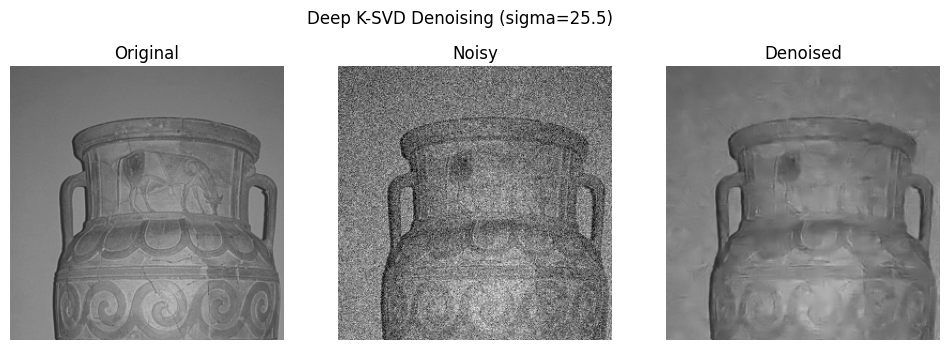

In [6]:
# Test on a single image
sigma_denom = 25.5  # sigma = 0.1 * 255 = 25.5
img = load_image(IMAGE_PATH / "0047.png")
img = img[:256, :256]

print(f"Image shape: {img.shape}, dtype: {img.dtype}")

# Denoise
X_rec, X_noisy = denoise_with_deep_ksvd(model, img, sigma=sigma_denom, device=device)

psnr_val = psnr(img, X_rec, data_range=255)
psnr_noisy = psnr(img, X_noisy, data_range=255)

print(f"Noisy PSNR: {psnr_noisy:.2f} dB")
print(f"Denoised PSNR: {psnr_val:.2f} dB")

show_results(img, X_rec, X_noisy=X_noisy, title=f"Deep K-SVD Denoising (sigma={sigma_denom})")


Image shape: (256, 256), dtype: float64
Noisy PSNR: 19.98 dB
Denoised PSNR: 26.43 dB


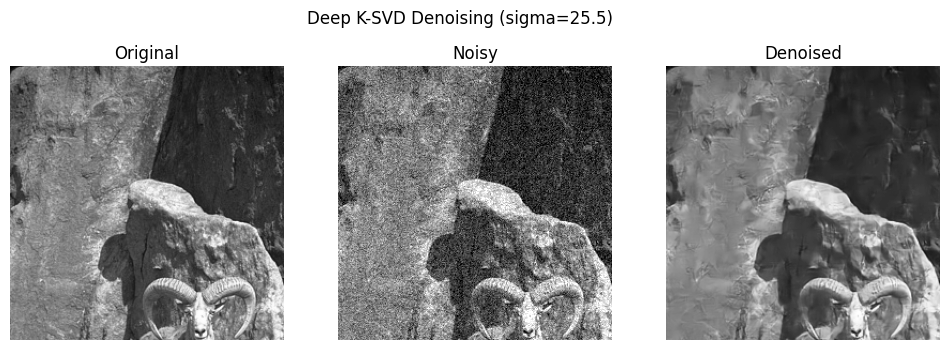

In [7]:
# Test on a single image
sigma_denom = 25.5  # sigma = 0.1 * 255 = 25.5
img = load_image(IMAGE_PATH / "0065.png")
img = img[:256, :256]

print(f"Image shape: {img.shape}, dtype: {img.dtype}")

# Denoise
X_rec, X_noisy = denoise_with_deep_ksvd(model, img, sigma=sigma_denom, device=device)

psnr_val = psnr(img, X_rec, data_range=255)
psnr_noisy = psnr(img, X_noisy, data_range=255)

print(f"Noisy PSNR: {psnr_noisy:.2f} dB")
print(f"Denoised PSNR: {psnr_val:.2f} dB")

show_results(img, X_rec, X_noisy=X_noisy, title=f"Deep K-SVD Denoising (sigma={sigma_denom})")


## Deep K-SVD Reconstruction

Single-image reconstruction with 40% missing pixels using the loaded Deep K-SVD denoising checkpoint (PnP).


In [8]:
# Reconstruction setup
recon_img = load_image(IMAGE_PATH / "0047.png")
recon_img = recon_img[:256, :256]
missing_fraction = 0.4
observed_fraction = 1 - missing_fraction

mask = create_mask(recon_img.shape, observed_fraction=observed_fraction, seed=42)
X_corrupted = recon_img.copy()
X_corrupted[~mask] = 0

print(f"Image shape: {recon_img.shape}")
print(f"Missing fraction: {missing_fraction}")
print(f"Observed fraction: {observed_fraction}")
print(f"Observed pixels: {mask.mean():.4f}")


Image shape: (256, 256)
Missing fraction: 0.4
Observed fraction: 0.6
Observed pixels: 0.5970


In [ ]:
# PnP-style reconstruction loop, matching the evaluate script
mean, std = 127.5, 127.5
X_current = X_corrupted.copy()

for _ in range(10):
    # Normalize to [-1, 1]
    X_norm = (X_current - mean) / std

    tensor = torch.from_numpy(X_norm).float().unsqueeze(0).unsqueeze(0).to(device)

    with torch.no_grad():
        pred_norm = model(tensor)[0, 0].cpu().numpy()
    
    # Denormalize back to [0, 255]
    X_denoised = pred_norm * std + mean
    X_current = mask * recon_img + (1 - mask) * X_denoised

X_rec = np.clip(X_current, 0, 255)

print(f"Reconstruction PSNR: {psnr(recon_img, X_rec, data_range=255):.2f} dB")
print(f"Reconstruction NRMSE: {nrmse(recon_img, X_rec, data_range=255):.4f}")


Reconstruction PSNR: 33.47 dB
Reconstruction NRMSE: 0.0212


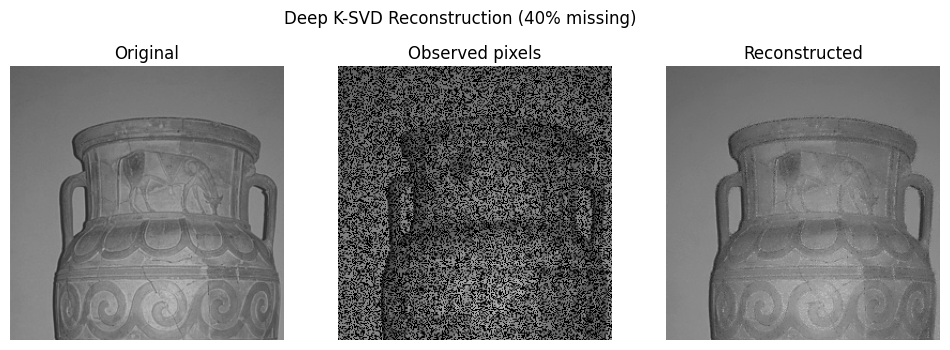

In [10]:
show_results(recon_img, X_rec, X_masked=X_corrupted, title="Deep K-SVD Reconstruction (40% missing)")


## Deep K-SVD Reconstruction

Single-image reconstruction with 40% missing pixels using the loaded Deep K-SVD checkpoint from the reconstruction training run.


In [4]:
# Load checkpoint
CKPT_PATH = Path(PROJECT_ROOT) / "results" / "deep_ksvd" / "checkpoints_recon" / "mf40" / "model_mf40_latest.pth"

print(f"Loading checkpoint: {CKPT_PATH}")
print(f"Checkpoint exists: {CKPT_PATH.exists()}")

if CKPT_PATH.exists():
    model = build_deep_ksvd_model(device)
    raw = torch.load(CKPT_PATH, map_location=device)
    state_dict = raw["model"] if "model" in raw else raw
    model.load_state_dict(state_dict)
    model.to(device)
    model.eval()
    
    n_iter = raw.get("iter", "?")
    print(f"Model loaded successfully (trained for {n_iter} iterations)")
else:
    print("Checkpoint not found!")


Loading checkpoint: /d/hpc/home/sm79111/thesis/results/deep_ksvd/checkpoints_recon/mf40/model_mf40_latest.pth
Checkpoint exists: True
Model loaded successfully (trained for 5500000 iterations)


Image shape       : (256, 256)
Missing fraction   : 0.4
Observed fraction  : 0.6
Observed pixels    : 0.5970
Reconstruction PSNR : 35.38 dB
Reconstruction NRMSE: 0.0170


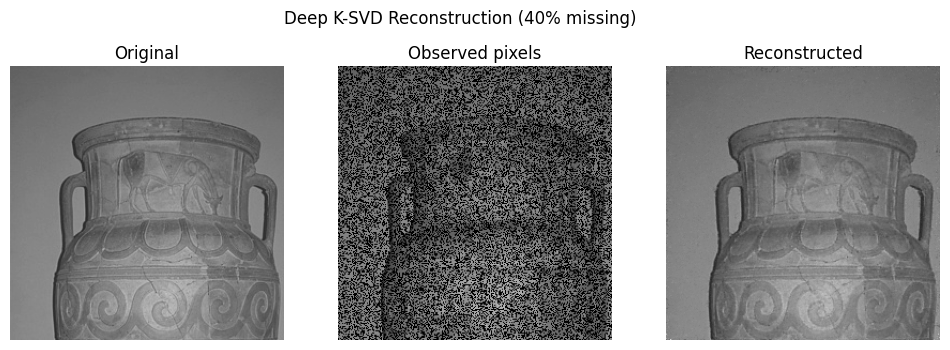

In [5]:
# Single-image reconstruction demo
recon_img = load_image(IMAGE_PATH / "0047.png")
recon_img = recon_img[:256, :256]

missing_fraction = 0.4
observed_fraction = 1 - missing_fraction
mask = create_mask(recon_img.shape, observed_fraction=observed_fraction, seed=42)
X_corrupted = recon_img.copy()
X_corrupted[~mask] = 0

print(f"Image shape       : {recon_img.shape}")
print(f"Missing fraction   : {missing_fraction}")
print(f"Observed fraction  : {observed_fraction}")
print(f"Observed pixels    : {mask.mean():.4f}")

mean, std = 127.5, 127.5
X_current = X_corrupted.copy()

# for _ in range(10):
X_norm = (X_current - mean) / std
tensor = torch.from_numpy(X_norm).float().unsqueeze(0).unsqueeze(0).to(device)
with torch.no_grad():
    pred_norm = model(tensor)[0, 0].cpu().numpy()
X_denoised = pred_norm * std + mean
X_current = mask * recon_img + (1 - mask) * X_denoised

X_rec = np.clip(X_current, 0, 255)

print(f"Reconstruction PSNR : {psnr(recon_img, X_rec, data_range=255):.2f} dB")
print(f"Reconstruction NRMSE: {nrmse(recon_img, X_rec, data_range=255):.4f}")

show_results(recon_img, X_rec, X_masked=X_corrupted, title="Deep K-SVD Reconstruction (40% missing)")


## Deep K-SVD on the Netflix dataset

### Denoising test with symmetric noise level p=0.1

Scripts: deep_ksvd_recommender_denoising.py and run_deep_ksvd_recommender_denoising.sh (-> SLURM output dksvd-recom-denoise-16943154.out)

Shape    : 4367 users × 256 movies
Observed : 1034723 / 1117952 (92.6%)

Noise RMSE : 0.6669

Training for 200 epochs over 4367 users


DENOISING RESULTS
- Noise RMSE (before)               : 0.6669
- RMSE all observed  (after)        : 0.5453
- MAE  all observed  (after)        : 0.2900
- RMSE corrupted entries (after)    : 1.5026
- RMSE clean entries (after)        : 0.2830

-> model should be evaluated on an unseen set of data, otherwise it is overly optimistic

In [3]:
RECOMMENDER_PATH = RESULTS_PATH / "recommender"

rec = pd.read_csv(RECOMMENDER_PATH / "reconstruction" / "reconstruction_results_summary_mf040.csv")
den_005 = pd.read_csv(RECOMMENDER_PATH / "denoising" / "denoising_results_summary_p005.csv")
den_01 = pd.read_csv(RECOMMENDER_PATH / "denoising" / "denoising_results_summary_p010.csv")
den_02 = pd.read_csv(RECOMMENDER_PATH / "denoising" / "denoising_results_summary_p020.csv")

In [7]:
den_005

,metric,mean,std
0,rmse_all_observed,0.417408,0.001452
1,mae_all_observed,0.175013,0.003171
2,psnr,19.630023,0.030195
3,rmse_corrupted_entries,1.700572,0.013367
4,rmse_clean_entries,0.175222,0.004195
5,seed,2.000000,1.581139


In [5]:
den_01

,metric,mean,std
0,rmse_all_observed,0.547003,0.003005
1,mae_all_observed,0.286346,0.005397
2,psnr,17.281511,0.047792
3,rmse_corrupted_entries,1.511996,0.003622
4,rmse_clean_entries,0.280415,0.003722
5,seed,2.000000,1.581139


In [8]:
den_02

,metric,mean,std
0,rmse_all_observed,0.702743,0.003264
1,mae_all_observed,0.456269,0.003402
2,psnr,15.105347,0.040307
3,rmse_corrupted_entries,1.316408,0.004995
4,rmse_clean_entries,0.429471,0.002789
5,seed,2.000000,1.581139


In [9]:
print("Netflix reconstruction test for 0.4 missing entries: ")

rec

Netflix reconstruction test for 0.4 missing entries: 


,metric,mean,std
0,rmse,0.989568,4.067953e-07
1,mae,0.806341,2.031863e-06
2,psnr,12.132283,3.570625e-06
3,seed,2.000000,1.581139e+00
